# Student Performance EDA & Insights Generation

In [592]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

print("Libraries loaded succefully")

Libraries loaded succefully


## 2. Data Loading & Overview

In [593]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print("\n--------------Dataset shaep-----------------")
print(f"Rows: {df.shape[0]}, columns: {df.shape[1]}")

print("\n-------------Columns names-------------")
print(df.columns.tolist())

print("\n---------------First 5 rows----------")
display(df.head())

print("\n----------Data Types & Non-Null Count-----")
print(df.info())


--------------Dataset shaep-----------------
Rows: 6607, columns: 20

-------------Columns names-------------
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

---------------First 5 rows----------


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



----------Data Types & Non-Null Count-----
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              66

## 3. Data Quality Assessment

In [594]:
print("\n--------Missing Values------")
missing = df.isnull().sum()
missing_percent = (missing /len(df)) * 100
missing_df = pd.DataFrame({
    'missing Count':missing,
    'Percentage': missing_percent
})
print(missing_df[missing_df['missing Count'] > 0])

if missing_df['missing Count'].sum() == 0:
    print("No missing Values found")

print("\n Duplicate Rows------")
duplicates = df.duplicated().sum()
print(f"Duplicated rows found: {duplicates}")





--------Missing Values------
                          missing Count  Percentage
Teacher_Quality                      78    1.180566
Parental_Education_Level             90    1.362192
Distance_from_Home                   67    1.014076

 Duplicate Rows------
Duplicated rows found: 0


## 4. Univariate Analysis (Target Variable)


--- Target Variable: Exam_Score ---
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


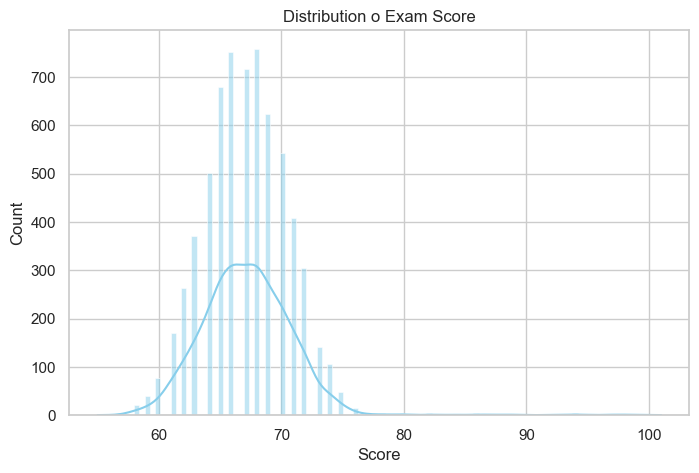

Skewness of Exam Score: 1.644808
Distribution is Right Skewed


In [595]:
print("\n--- Target Variable: Exam_Score ---")
print(df['Exam_Score'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True, color='skyblue')
plt.title("Distribution o Exam Score")
plt.xlabel('Score')
plt.show()

# Insight: Check for skewness
skewness = df['Exam_Score'].skew()
print(f"Skewness of Exam Score: {skewness:2f}")
if skewness > 0.5:
    print("Distribution is Right Skewed")
elif skewness < -0.5:
    print("Distribution is left-skewed")
else:
    print("Distribution is approximately normal")
    

## 5. Numerical Feature Analysis

-----Numerical Feature Summary ---------
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity  
count        6607.000000        6607.000000  
mean            1.493719           2.967610  
std             1.230570           1.031231  
min             0.000000           0.000000  
25%             1.000000           2.000000  
50%             1.000000           3.000000  
75%             2.000000         

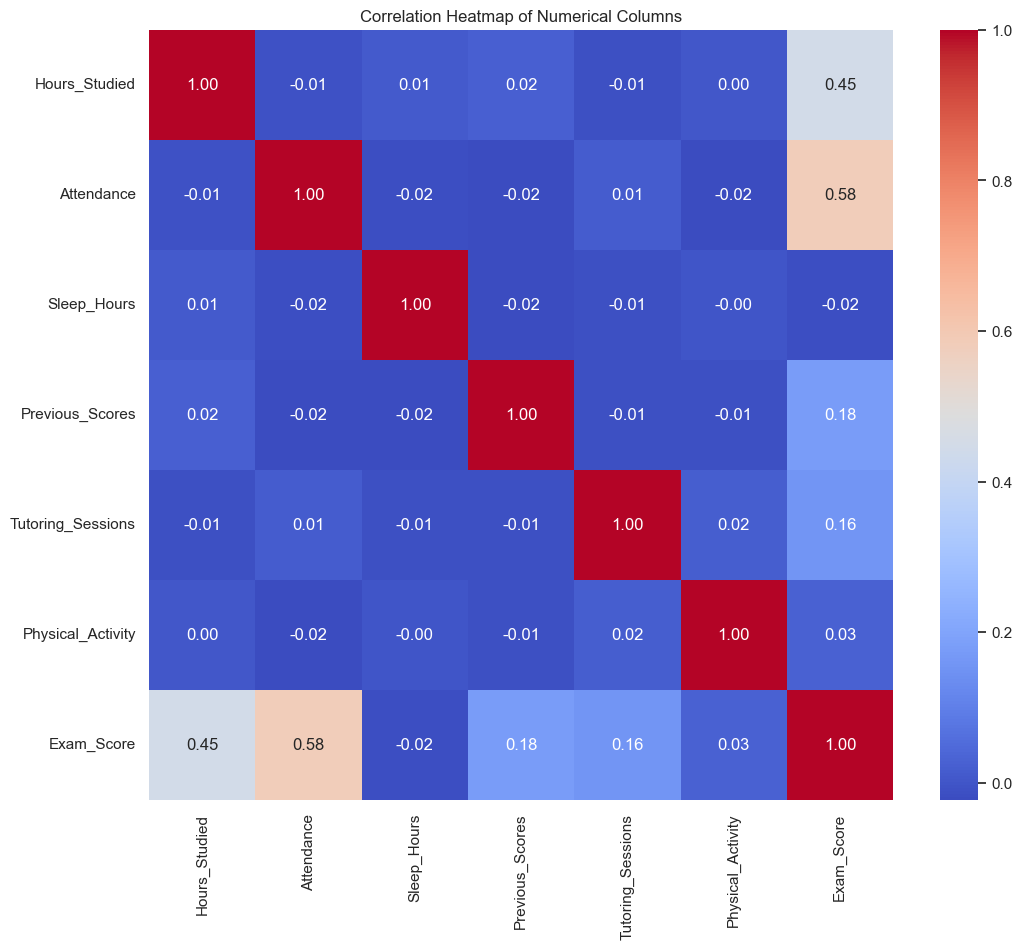


 Top 3 predictors (numerical): ['Attendance', 'Hours_Studied', 'Previous_Scores']


In [596]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from features list or correlation analysis
feature_cols = [col for col in num_cols if col !='Exam_Score']

print("-----Numerical Feature Summary ---------")
print(df[feature_cols].describe())

# Correlation with target 
print("\n------Correlation with Exam Score-----")
corr_with_target = df[feature_cols].corrwith(df['Exam_Score']).sort_values(ascending=False)
print(corr_with_target)

# Visulaize correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

# Key Insights printing
top_corr = corr_with_target.head(3)
print(f"\n Top 3 predictors (numerical): {top_corr.index.tolist()}")

# 6. Categorical Feature Analysis


----Categorcial Columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

------- Categorcial Impact on Exam Score-----

Parental_Involvement
Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: Exam_Score, dtype: float64


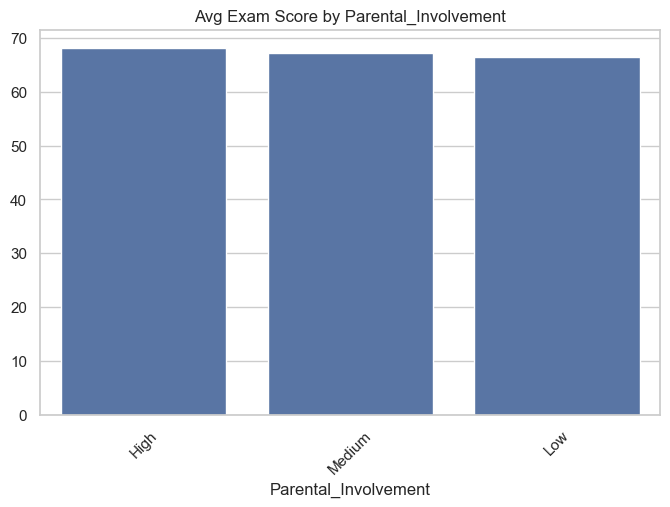


Access_to_Resources
Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64

Extracurricular_Activities
Extracurricular_Activities
Yes    67.441849
No     66.931435
Name: Exam_Score, dtype: float64

Motivation_Level
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64

Internet_Access
Internet_Access
Yes    67.292895
No     66.535070
Name: Exam_Score, dtype: float64

Family_Income
Family_Income
High      67.842396
Medium    67.334959
Low       66.848428
Name: Exam_Score, dtype: float64

Teacher_Quality
Teacher_Quality
High      67.676939
Medium    67.109299
Low       66.753425
Name: Exam_Score, dtype: float64

School_Type
School_Type
Private    67.287705
Public     67.212919
Name: Exam_Score, dtype: float64


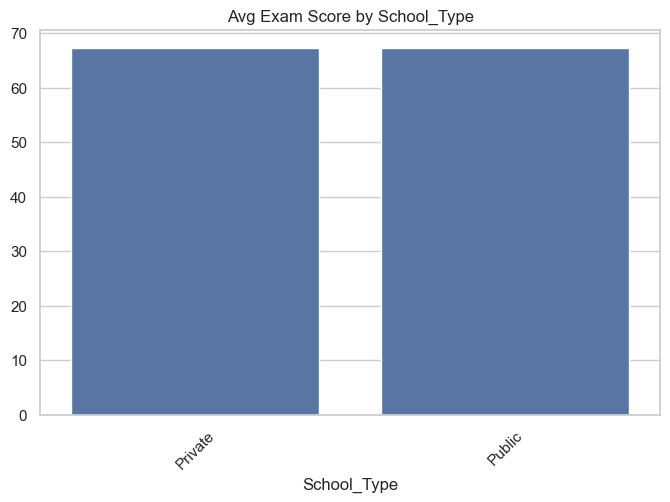


Peer_Influence
Peer_Influence
Positive    67.623199
Neutral     67.197917
Negative    66.564270
Name: Exam_Score, dtype: float64


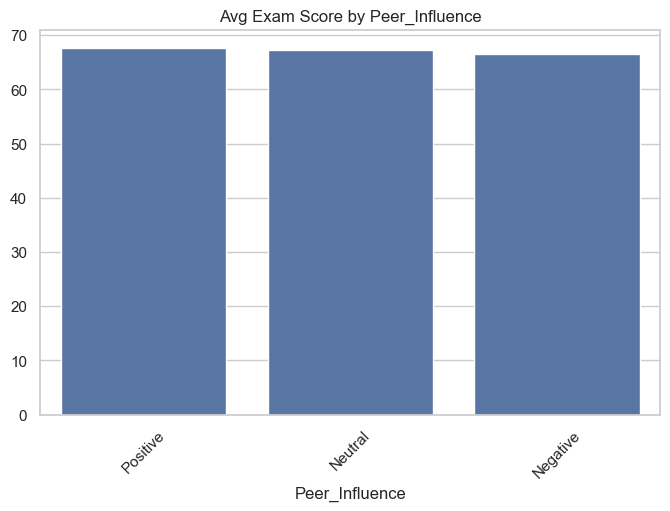


Learning_Disabilities
Learning_Disabilities
No     67.349120
Yes    66.270504
Name: Exam_Score, dtype: float64

Parental_Education_Level
Parental_Education_Level
Postgraduate    67.970881
College         67.315737
High School     66.893577
Name: Exam_Score, dtype: float64

Distance_from_Home
Distance_from_Home
Near        67.512101
Moderate    66.981481
Far         66.457447
Name: Exam_Score, dtype: float64

Gender
Gender
Female    67.244898
Male      67.228894
Name: Exam_Score, dtype: float64


In [597]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist() 
print(f"\n----Categorcial Columns: {cat_cols}")

#Analyze impact of categorcial features on score
print(f"\n------- Categorcial Impact on Exam Score-----")
for col in cat_cols:
    group_means = df.groupby(col)['Exam_Score'].mean().sort_values(ascending=False)
    print(f"\n{col}")
    print(group_means)

    # Plot top 5 categorical features
    if col in ['Parental_Involvement', 'School_Type', 'Peer_Influence']:
        plt.figure(figsize=(8, 5))
        sns.barplot(x=group_means.index, y=group_means.values)
        plt.title(f'Avg Exam Score by {col}')
        plt.xticks(rotation=45)
        plt.show()
        

## 7. BIVARIATE ANALYSIS (Key Relationships)

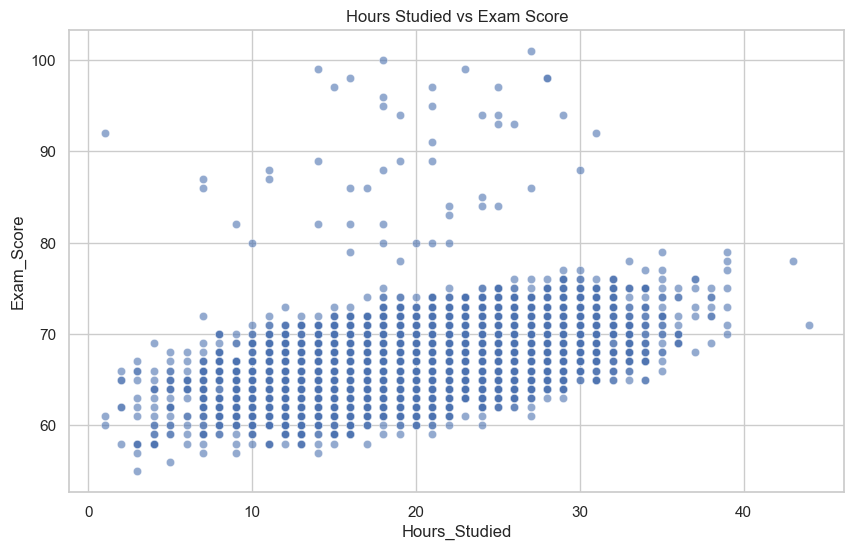

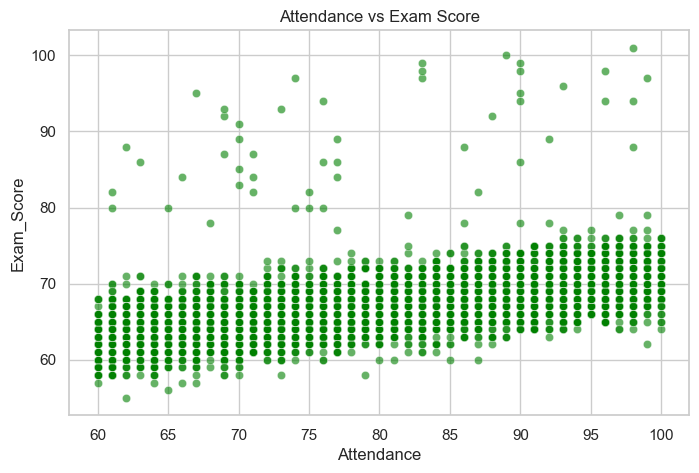

In [598]:
# study Hours vs Score
sns.scatterplot(x='Hours_Studied',y='Exam_Score', data=df, alpha=0.6)
plt.title("Hours Studied vs Exam Score")
plt.show()

#Attendance Vs Score
# Attendance vs Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, alpha=0.6, color='green')
plt.title('Attendance vs Exam Score')
plt.show()


## 8. OUTLIER DETECTION (IQR Method)


--- 🚨 Outlier Detection (IQR Method) ---
⚠️ Hours_Studied: 43 outliers detected (0.65%)
⚠️ Tutoring_Sessions: 430 outliers detected (6.51%)


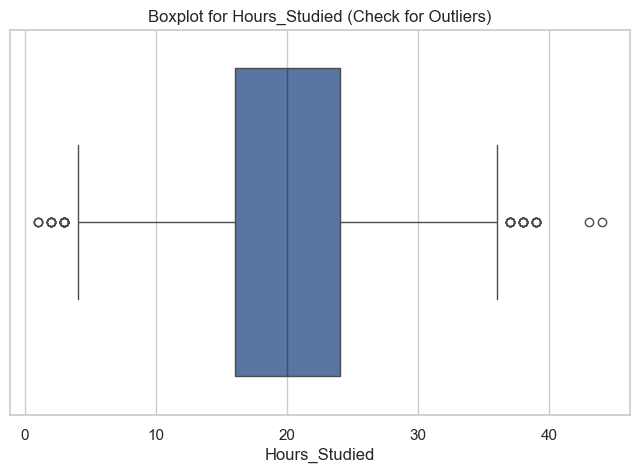

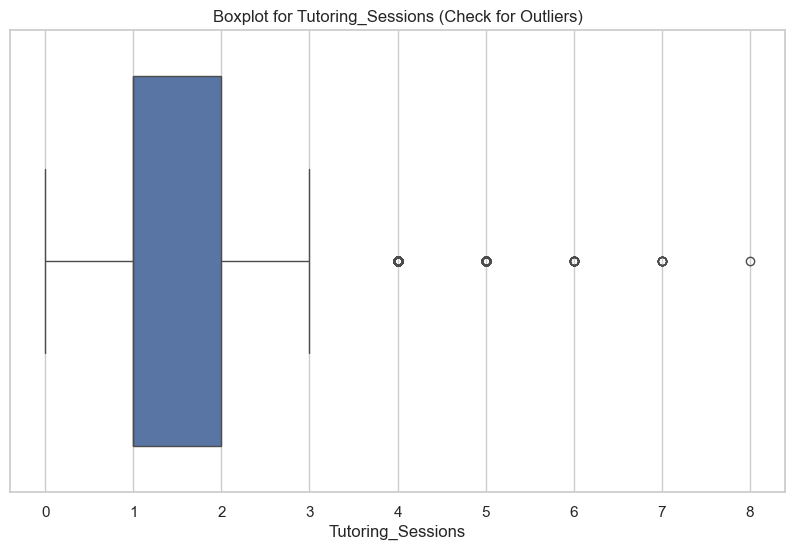

In [599]:
print("\n--- 🚨 Outlier Detection (IQR Method) ---")
outlier_summary = {}

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    outliers = df[(df[col]<(Q1-1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))]
    count = len(outliers)
    outlier_summary[col] = count
    if count >0:
        print(f"⚠️ {col}: {count} outliers detected ({(count/len(df))*100:.2f}%)")

# Visualize Outliers for Key Feature
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Hours_Studied'])
plt.title('Boxplot for Hours_Studied (Check for Outliers)')
plt.show()

sns.boxplot(x=df['Tutoring_Sessions'])
plt.title('Boxplot for Tutoring_Sessions (Check for Outliers)')
plt.show()

## 9. FINAL INSIGHTS SUMMARY

In [600]:
print("\n" + "="*50)
print(" AUTOMATED INSIGHTS SUMMARY")
print("="*50)

# 1. Data Quality
if duplicates == 0 and missing_df['missing Count'].sum() == 0:
    print(" Data Quality: Clean (No duplicates, no missing values).")
else:
    print(" Data Quality: Requires cleaning.")

# 2. Top Predictors
print(f" Strongest Numerical Predictor: {corr_with_target.index[0]} (Corr: {corr_with_target.iloc[0]:.2f})")

# 3. Target Stats
print(f" Avg Exam Score: {df['Exam_Score'].mean():.2f}")
print(f" Score Range: {df['Exam_Score'].min()} - {df['Exam_Score'].max()}")

# 4. Outliers
total_outliers = sum(outlier_summary.values())
print(f" Total Outlier Instances Across Features: {total_outliers}")

print("="*50)


 AUTOMATED INSIGHTS SUMMARY
 Data Quality: Requires cleaning.
 Strongest Numerical Predictor: Attendance (Corr: 0.58)
 Avg Exam Score: 67.24
 Score Range: 55 - 101
 Total Outlier Instances Across Features: 473


# DATA PREPROCESSING 

In [601]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('StudentPerformanceFactors.csv')

print(f" Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

 Dataset loaded: 6607 rows, 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Handle Missing Values

In [602]:
print("\n---  Missing Values Analysis ---")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])


# For Categorical columns with <5% missingL Mode Imputatiton
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value,inplace=True)
        print(f" {col}: Filled {df[col].isnull().sum()} missing values with mode '{mode_value}'")

# For numerical columns: Median imputation (robust to outliers)
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].meadian()
        df[col].fillna(median_value, inplace=True)
        print(f" {col}: Filled {df[col].isnull().sum()} missing values with median {median_value}")


print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")


---  Missing Values Analysis ---
                          Missing Count  Percentage
Teacher_Quality                      78        1.18
Parental_Education_Level             90        1.36
Distance_from_Home                   67        1.01
 Teacher_Quality: Filled 78 missing values with mode 'Medium'
 Parental_Education_Level: Filled 90 missing values with mode 'High School'
 Distance_from_Home: Filled 67 missing values with mode 'Near'

Total missing values remaining: 235


## Handle Outliers


---  Outlier Detection & Treatment ---
 Hours_Studied: 43 outliers (0.65%) | Bounds: [4.00, 36.00]
 Attendance: 0 outliers (0.00%) | Bounds: [40.00, 120.00]
 Sleep_Hours: 0 outliers (0.00%) | Bounds: [3.00, 11.00]
 Previous_Scores: 0 outliers (0.00%) | Bounds: [25.50, 125.50]
 Exam_Score: 104 outliers (1.57%) | Bounds: [59.00, 75.00]

--- 🔧 Outlier Treatment (Winsorization) ---
 Hours_Studied: Capped outliers to bounds [4.00, 36.00]
 Exam_Score: Capped to [0, 100]


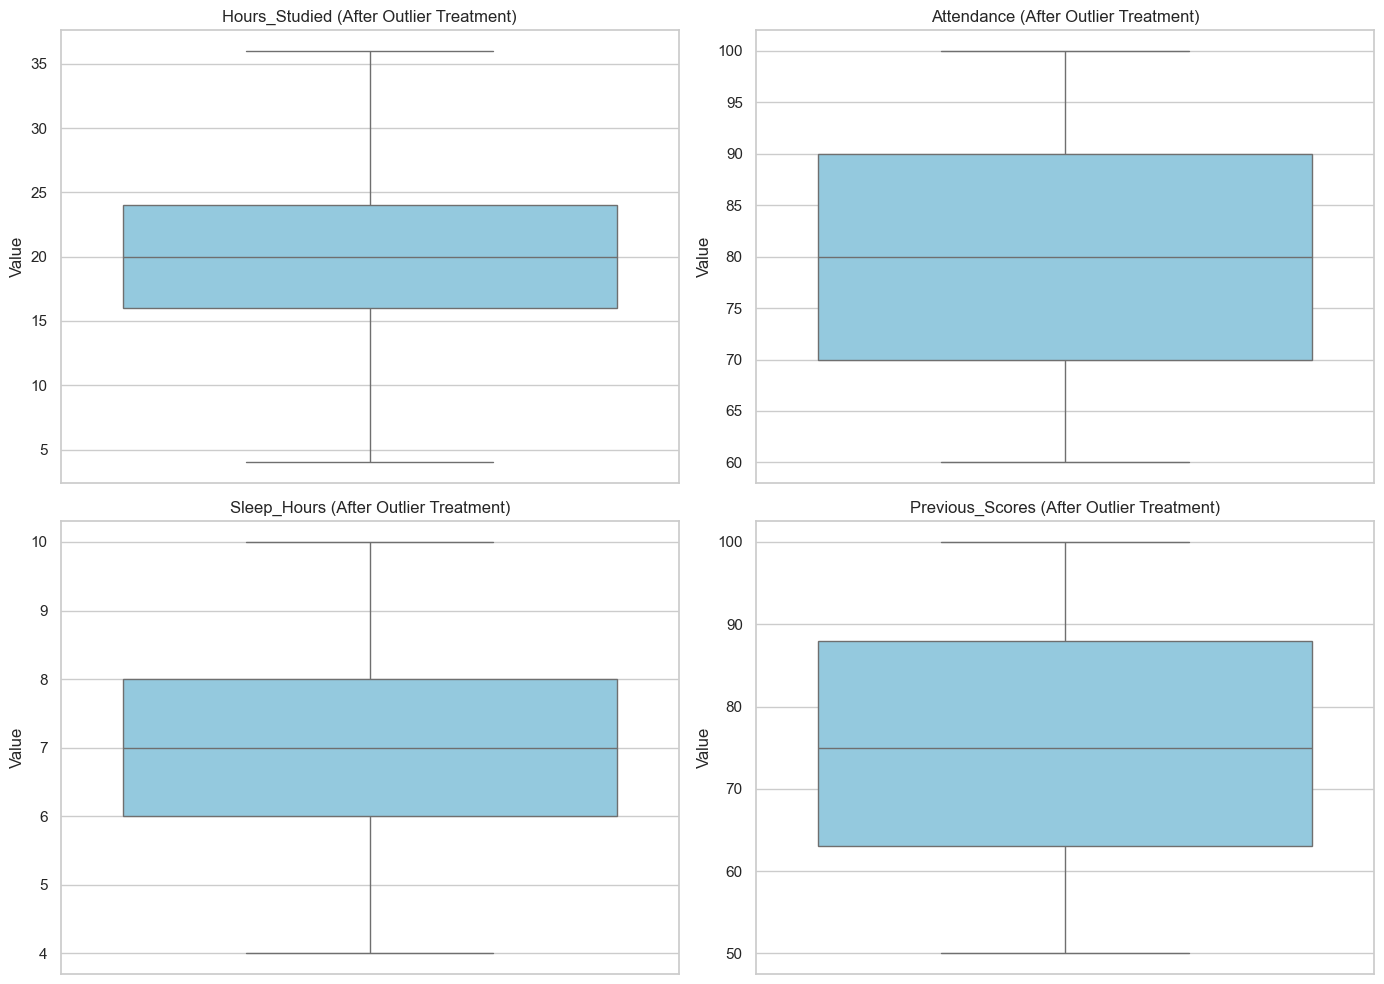

In [603]:
print("\n---  Outlier Detection & Treatment ---")

# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in key numerical features
outlier_summary = {}
for col in ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Exam_Score']:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    outlier_summary[col] = {
        'count': outlier_count,
        'percentage': outlier_percentage,
        'bounds': (lower, upper)
    }
    print(f" {col}: {outlier_count} outliers ({outlier_percentage:.2f}%) | Bounds: [{lower:.2f}, {upper:.2f}]")

# Treatment Strategy: Cap outliers at bounds (winsorization)
print("\n--- 🔧 Outlier Treatment (Winsorization) ---")
for col in ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        df[col] = df[col].clip(lower, upper)
        print(f" {col}: Capped outliers to bounds [{lower:.2f}, {upper:.2f}]")

# For Exam_Score (target): Cap at 0-100 (logical bounds)
df['Exam_Score'] = df['Exam_Score'].clip(0, 100)
print(f" Exam_Score: Capped to [0, 100]")

# Visualize before/after
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cols_to_plot = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(f'{col} (After Outlier Treatment)')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [604]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [605]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 4: Encode Categorical Variables

In [606]:
import pandas as pd

print("\n---  Categorical Variable Encoding (SAFE VERSION) ---")

# -----------------------------
# 0. Defensive copy (important)
# -----------------------------
df = df.copy()

# -----------------------------
# 1. Normalize categorical text
# -----------------------------
cat_cols = [
    'Parental_Education_Level',
    'Distance_from_Home',
    'Family_Income',
    'Teacher_Quality',
    'Peer_Influence',
    'Motivation_Level',
    'Parental_Involvement',
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Internet_Access',
    'Learning_Disabilities'
]

for col in cat_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
        )
        df[col] = df[col].fillna("Unknown")



    df[col] = df[col].fillna("Unknown")
# -----------------------------
# 2. Ordinal mappings
# -----------------------------
ordinal_mappings = {
    'Parental_Involvement': {
        'Low': 1, 'Medium': 2, 'High': 3
    },
    'Access_to_Resources': {
        'Low': 1, 'Medium': 2, 'High': 3
    },
    'Motivation_Level': {
        'Low': 1, 'Medium': 2, 'High': 3
    },
    'Family_Income': {
        'Low': 1, 'Medium': 2, 'High': 3
    },
    'Teacher_Quality': {
    'Low': 1, 'Medium': 2, 'High': 3, 'Unknown': 0},
    'Parental_Education_Level': {
    'High School': 1,
    'College': 2,
    'Postgraduate': 3,
    'Unknown': 0
    },
    'Peer_Influence': {
        'Negative': 1, 'Neutral': 2, 'Positive': 3 , 'Unknown': 0
    },
    'Distance_from_Home': {
        'Far': 1, 'Moderate': 2, 'Near': 3, 'Unknown': 0
    }
}

print("\n Ordinal Encoding:")
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        # Validate categories BEFORE encoding
        unseen = set(df[col].unique()) - set(mapping.keys())
        if unseen:
            raise ValueError(f" {col} has unseen categories: {unseen}")

        # SAFE encoding
        df[col] = df[col].replace(mapping).astype("Int64")
        print(f" {col} encoded")

# -----------------------------
# 3. Binary mappings
# -----------------------------
binary_mappings = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1}
}

print("\n Binary Encoding:")
for col, mapping in binary_mappings.items():
    if col in df.columns:
        unseen = set(df[col].unique()) - set(mapping.keys())
        if unseen:
            raise ValueError(f" {col} has unseen categories: {unseen}")

        df[col] = df[col].replace(mapping).astype("Int64")
        print(f" {col} encoded")

# -----------------------------
# 4. One-Hot Encoding (Nominal)
# -----------------------------
nominal_cols = ['School_Type', 'Gender']

print("\n One-Hot Encoding:")
df = pd.get_dummies(
    df,
    columns=[c for c in nominal_cols if c in df.columns],
    drop_first=True
)

# -----------------------------
# 5. Final integrity checks
# -----------------------------
encoded_cols = list(ordinal_mappings.keys()) + list(binary_mappings.keys())

na_report = df[encoded_cols].isna().sum()
if na_report.sum() != 0:
    raise RuntimeError(
        f" Encoding introduced NaNs:\n{na_report}"
    )

print("\n Encoding complete — no missing values introduced")
print(f" Final dataset shape: {df.shape}")



---  Categorical Variable Encoding (SAFE VERSION) ---

 Ordinal Encoding:
 Parental_Involvement encoded
 Access_to_Resources encoded
 Motivation_Level encoded
 Family_Income encoded
 Teacher_Quality encoded
 Parental_Education_Level encoded
 Peer_Influence encoded
 Distance_from_Home encoded

 Binary Encoding:
 Extracurricular_Activities encoded
 Internet_Access encoded
 Learning_Disabilities encoded

 One-Hot Encoding:

 Encoding complete — no missing values introduced
 Final dataset shape: (6607, 20)


## 5: Feature Engineering

In [607]:
print("\n---  Feature Engineering (LEAK-FREE) ---")

df['Study_Effort'] = df['Hours_Studied']
print(" Created: Study_Effort (Hours_Studied)")


df['Attendance_Score'] = df['Attendance'] * df['Previous_Scores'] / 100
print(" Created: Attendance_Score (Attendance × Previous_Scores / 100)")

# 3. Support System Composite
df['Support_System'] = (
    df['Parental_Involvement'] +
    df['Access_to_Resources'] +
    df['Teacher_Quality']
) / 3
print(" Created: Support_System")

# 4. Sleep quality
df['Optimal_Sleep'] = (
    (df['Sleep_Hours'] >= 6) &
    (df['Sleep_Hours'] <= 8)
).astype(int)
print(" Created: Optimal_Sleep")

# 5. Study intensity
df['High_Intensity_Study'] = (df['Hours_Studied'] > 25).astype(int)
print(" Created: High_Intensity_Study")

# 6. Risk factor
df['Risk_Factor'] = (
    (df['Attendance'] < 70) &
    (df['Motivation_Level'] == 1)
).astype(int)
print(" Created: Risk_Factor")

print(f"\n Total features after engineering: {df.shape[1]}")



---  Feature Engineering (LEAK-FREE) ---
 Created: Study_Effort (Hours_Studied)
 Created: Attendance_Score (Attendance × Previous_Scores / 100)
 Created: Support_System
 Created: Optimal_Sleep
 Created: High_Intensity_Study
 Created: Risk_Factor

 Total features after engineering: 26


## Feature Selection


Top 10 Features by Correlation with Exam_Score:
Attendance              0.581205
Attendance_Score        0.493097
Hours_Studied           0.445489
Study_Effort            0.445489
High_Intensity_Study    0.312761
Support_System          0.238124
Previous_Scores         0.175089
Access_to_Resources     0.169832
Parental_Involvement    0.157227
Tutoring_Sessions       0.156466
dtype: float64

 Bottom 5 Features by Correlation with Exam_Score:
Optimal_Sleep           -0.005653
School_Type_Public      -0.008872
Sleep_Hours             -0.017000
Learning_Disabilities   -0.085081
Risk_Factor             -0.257295
dtype: float64

 Low correlation features (|r| < 0.1): ['Family_Income', 'Distance_from_Home', 'Motivation_Level', 'Teacher_Quality', 'Extracurricular_Activities', 'Internet_Access', 'Physical_Activity', 'Gender_Male', 'Optimal_Sleep', 'School_Type_Public', 'Sleep_Hours', 'Learning_Disabilities']


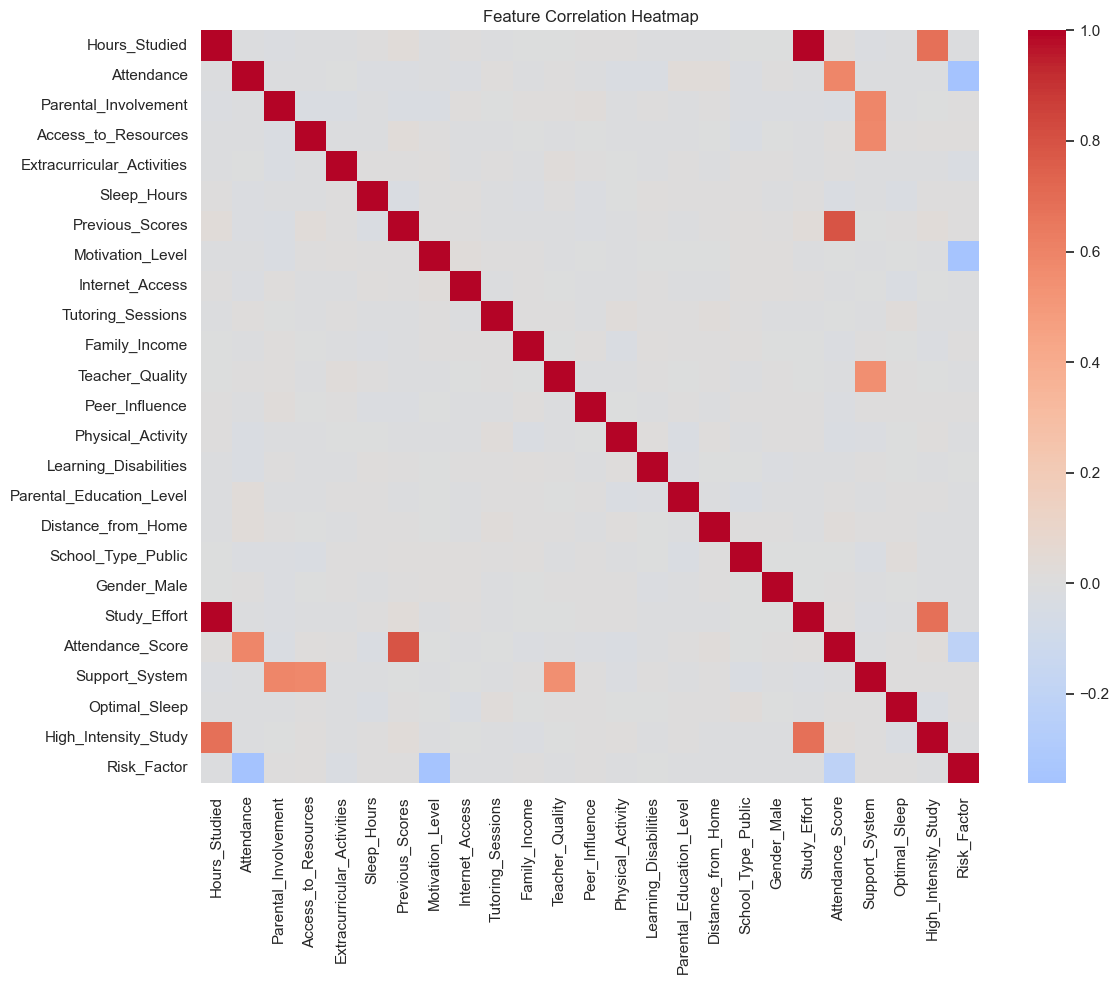

In [608]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Calculate correlation with target
correlation_with_target = X.corrwith(y).sort_values(ascending=False)
print("\nTop 10 Features by Correlation with Exam_Score:")
print(correlation_with_target.head(10))

print("\n Bottom 5 Features by Correlation with Exam_Score:")
print(correlation_with_target.tail(5))

# Identify low-correlation features (< 0.1)
low_corr_features = correlation_with_target[abs(correlation_with_target) < 0.1].index.tolist()
print(f"\n Low correlation features (|r| < 0.1): {low_corr_features}")

# Check for multicollinearity (features highly correlated with each other)
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()



## Feature Scaling

In [609]:
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print(" StandardScaler applied to numerical features")
print(f"\n Scaling verification (should be ~0 mean, ~1 std):")
print(f"Mean: {X_scaled[numerical_features].mean().round(4)}")
print(f"Std: {X_scaled[numerical_features].std().round(4)}")

 StandardScaler applied to numerical features

 Scaling verification (should be ~0 mean, ~1 std):
Mean: Hours_Studied                -0.0
Attendance                   -0.0
Parental_Involvement         -0.0
Access_to_Resources           0.0
Extracurricular_Activities    0.0
Sleep_Hours                  -0.0
Previous_Scores               0.0
Motivation_Level              0.0
Internet_Access              -0.0
Tutoring_Sessions             0.0
Family_Income                -0.0
Teacher_Quality              -0.0
Peer_Influence               -0.0
Physical_Activity            -0.0
Learning_Disabilities        -0.0
Parental_Education_Level      0.0
Distance_from_Home           -0.0
Study_Effort                 -0.0
Attendance_Score              0.0
Support_System                0.0
Optimal_Sleep                -0.0
High_Intensity_Study         -0.0
Risk_Factor                  -0.0
dtype: float64
Std: Hours_Studied                 1.0001
Attendance                    1.0001
Parental_Involvement

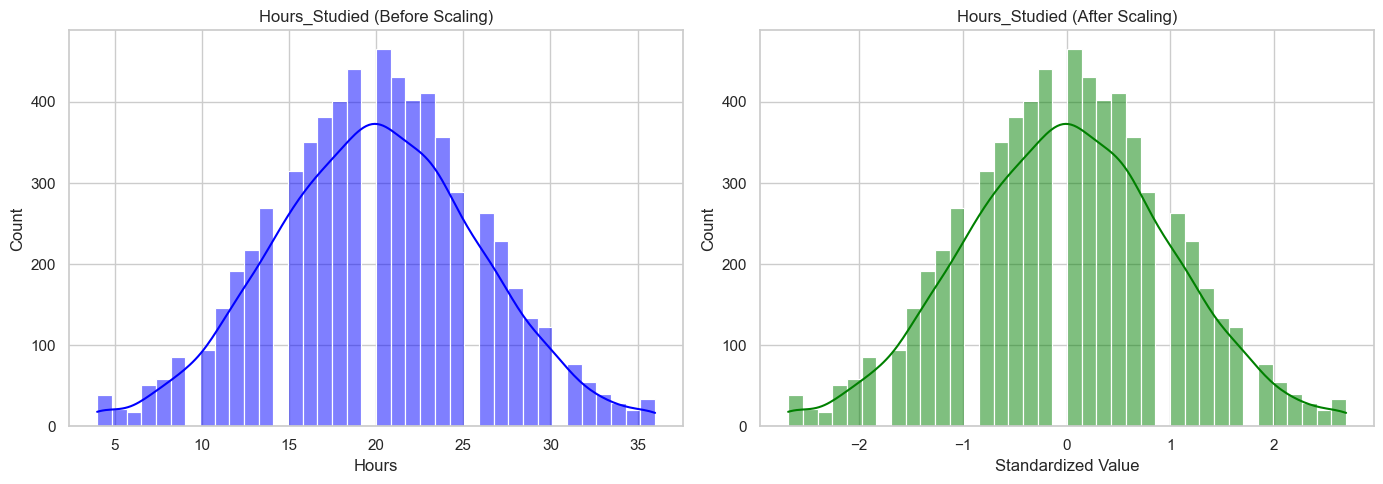

In [610]:
# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
sns.histplot(X['Hours_Studied'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Hours_Studied (Before Scaling)')
axes[0].set_xlabel('Hours')

# After scaling
sns.histplot(X_scaled['Hours_Studied'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Hours_Studied (After Scaling)')
axes[1].set_xlabel('Standardized Value')

plt.tight_layout()
plt.show()

## Train-Test Split

In [611]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=None, 
)

print(f" Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f" Total features: {X_train.shape[1]}")

# Verify target distribution in train/test
print("\nTarget Variable Distribution:")
print(f"Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

 Training set: 5285 samples (80.0%)
 Testing set: 1322 samples (20.0%)
 Total features: 25

Target Variable Distribution:
Train - Mean: 67.21, Std: 3.92
Test  - Mean: 67.32, Std: 3.76


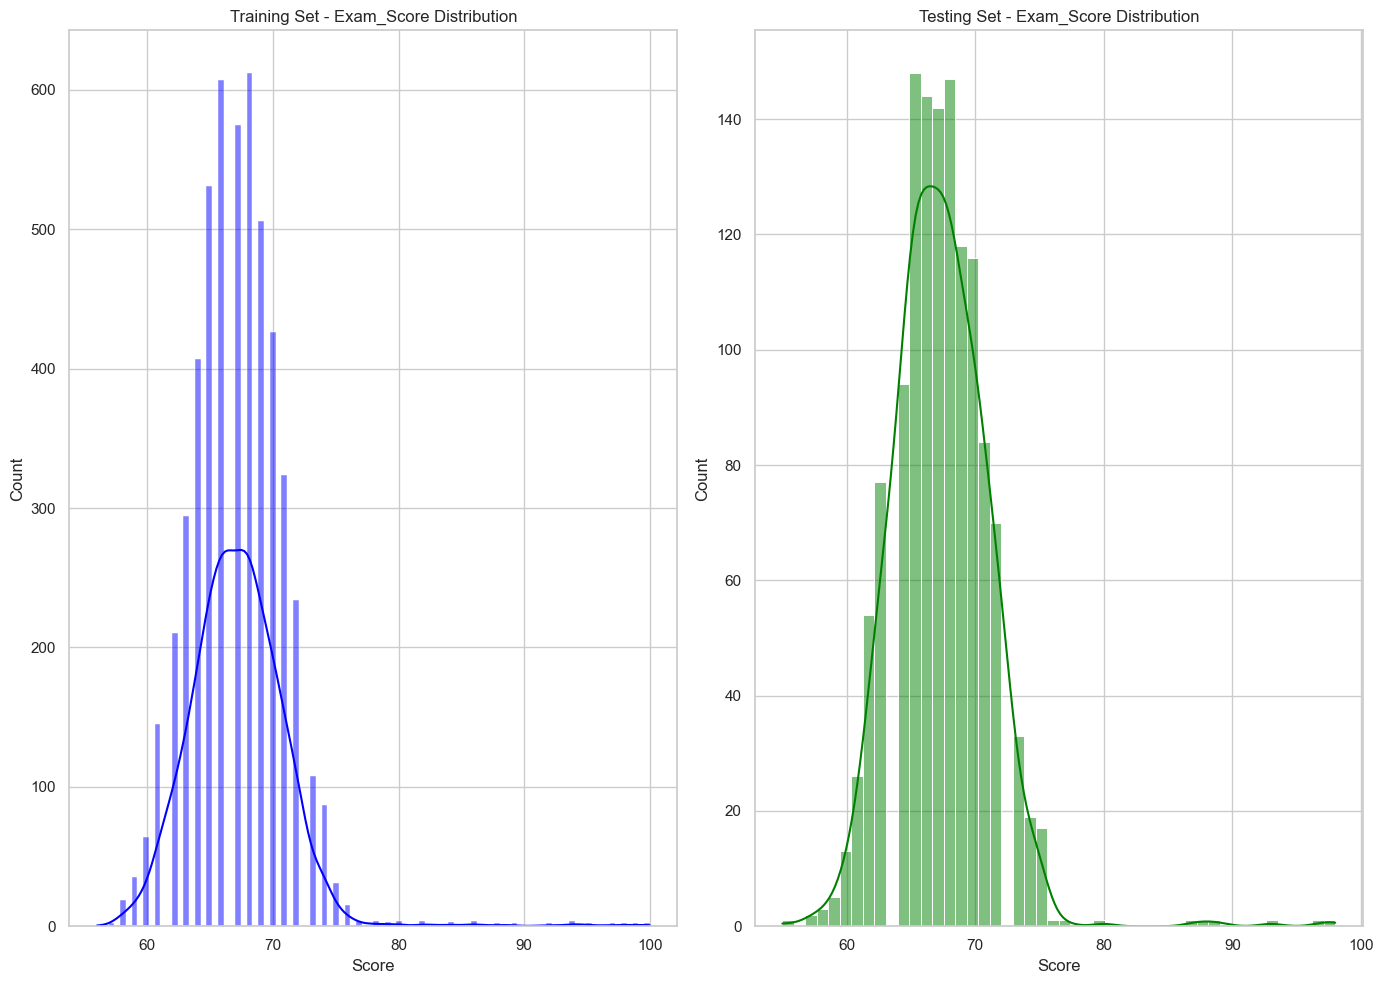

In [612]:
# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

sns.histplot(y_train, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Training Set - Exam_Score Distribution')
axes[0].set_xlabel('Score')

sns.histplot(y_test, kde=True, ax=axes[1], color='green')
axes[1].set_title('Testing Set - Exam_Score Distribution')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

# Model Training and Evaluation

In [613]:
# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

In [614]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

# make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true,y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

train_metrics = evaluate_model(y_train, y_train_pred)
test_metrics = evaluate_model(y_test, y_test_pred)

print("\n---  Linear Regression Performance ---")
print(f"{'Metric':<10} | {'Train':<10} | {'Test':<10}")
for key in train_metrics.keys():
    print(f"{key:<10} | {train_metrics[key]:<10.4f} | {test_metrics[key]:<10.4f}")



---  Linear Regression Performance ---
Metric     | Train      | Test      
MSE        | 4.3513     | 3.2830    
RMSE       | 2.0860     | 1.8119    
MAE        | 0.5268     | 0.4774    
R²         | 0.7169     | 0.7677    


## Interpret Coefficients

In [615]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n---  Top 5 Positive Impact Features ---")
print(coefficients.head(5))
print("\n---  Top 5 Negative Impact Features ---")
print(coefficients.tail(5))


---  Top 5 Positive Impact Features ---
              Feature  Coefficient
1          Attendance     1.935988
19       Study_Effort     0.871737
0       Hours_Studied     0.871737
9   Tutoring_Sessions     0.625634
20   Attendance_Score     0.568742

---  Top 5 Negative Impact Features ---
                  Feature  Coefficient
22          Optimal_Sleep    -0.002548
5             Sleep_Hours    -0.020695
18            Gender_Male    -0.034380
24            Risk_Factor    -0.047753
14  Learning_Disabilities    -0.263572


## Visualize Predictions

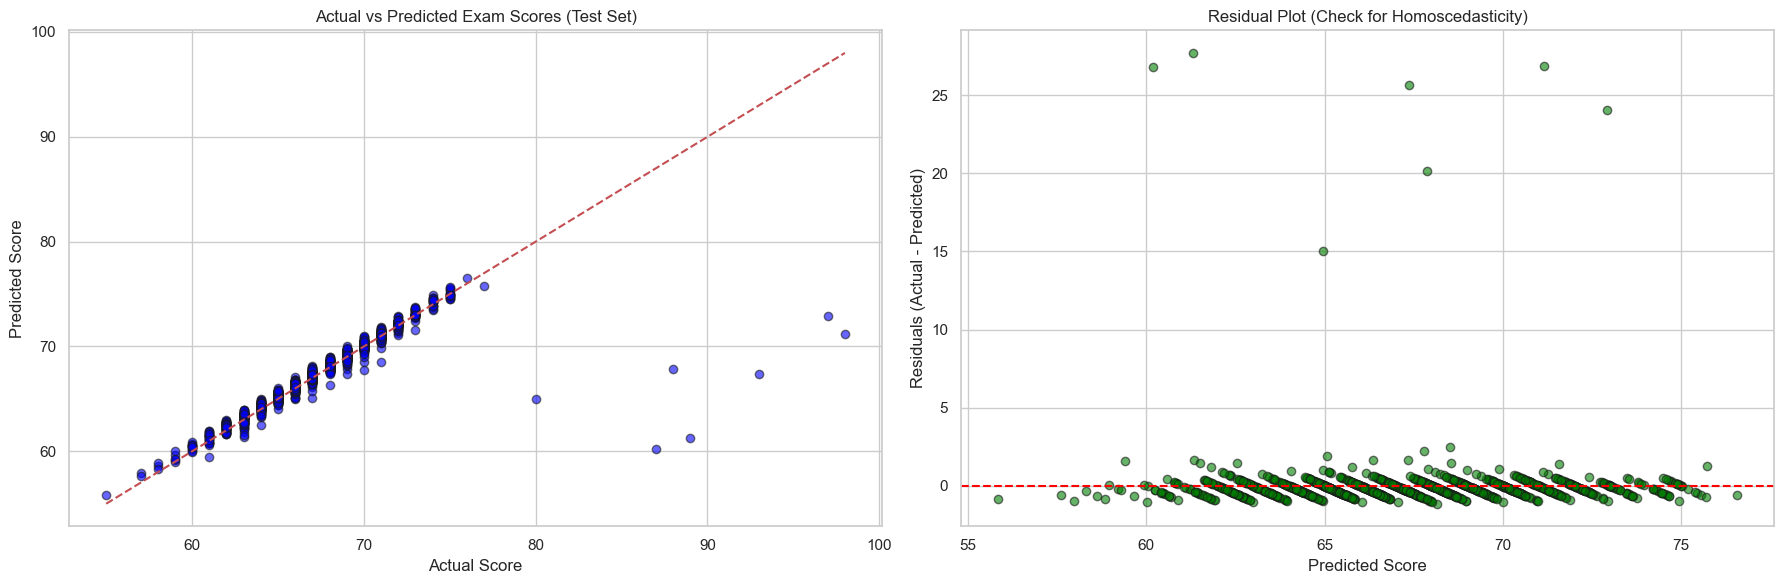

Text(0.5, 1.0, 'Top 10 Most Influential Features (Absolute Coefficient)')

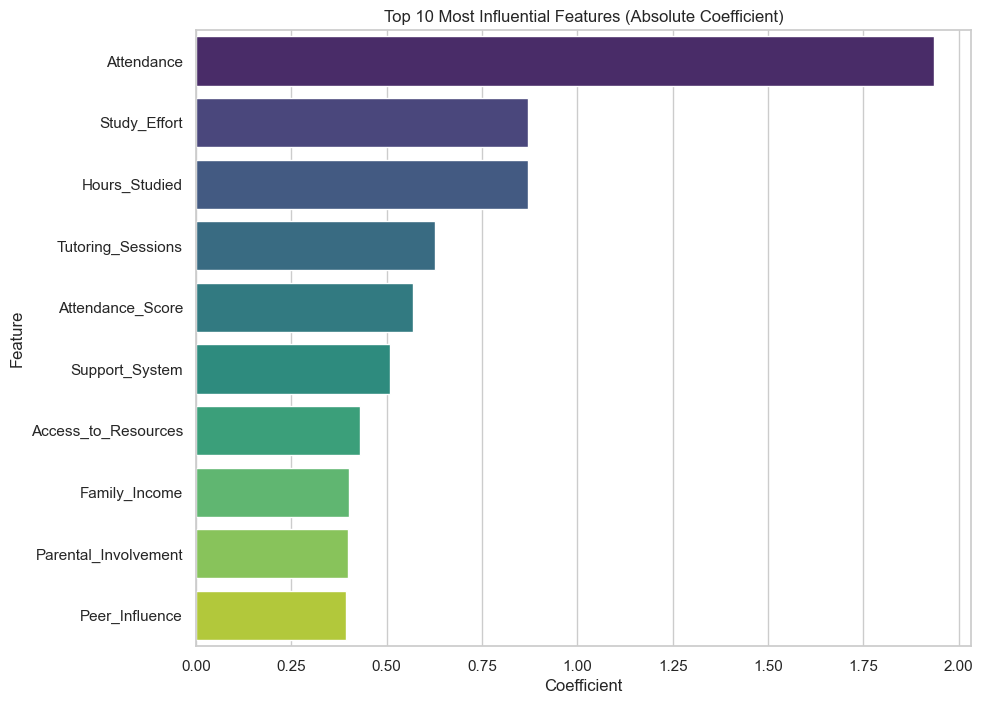

In [616]:
# ---------------------------------------------------------
# 7. VISUALIZE PREDICTIONS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted Exam Scores (Test Set)')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].grid(True)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, color='green', edgecolors='k')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual Plot (Check for Homoscedasticity)')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. FEATURE IMPORTANCE PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Create a temporary column with absolute values for sorting
coefficients['abs_coef'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='abs_coef', ascending=False).head(10)
# Drop the temporary column 
top_features = top_features.drop('abs_coef', axis=1)

sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Most Influential Features (Absolute Coefficient)')

# Bonus: Polynomial Regression

In [617]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)

y_test_pred_poly = poly_model.predict(X_test_poly)
poly_metrics = evaluate_model(y_test, y_test_pred_poly)

print("\n---  Model Comparison ---")
print(f"{'Model':<20} | {'Test R²':<10} | {'Test RMSE':<10}")
print("-" * 45)
print(f"{'Linear Regression':<20} | {test_metrics['R²']:<10.4f} | {test_metrics['RMSE']:<10.4f}")
print(f"{'Polynomial (Deg 2)':<20} | {poly_metrics['R²']:<10.4f} | {poly_metrics['RMSE']:<10.4f}")

# Visualize Improvement
if poly_metrics['R²'] > test_metrics['R²']:
    print("\n Polynomial Regression improved performance!")
else:
    print("\n Polynomial Regression did not significantly improve performance (Risk of Overfitting).")


---  Model Comparison ---
Model                | Test R²    | Test RMSE 
---------------------------------------------
Linear Regression    | 0.7677     | 1.8119    
Polynomial (Deg 2)   | 0.7544     | 1.8630    

 Polynomial Regression did not significantly improve performance (Risk of Overfitting).


K mean clustering

In [618]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cluster_features = [
    'Exam_Score',
    'Hours_Studied',
    'Attendance',
    'Motivation_Level'
]

X_cluster = df[cluster_features]

# Scaling is essential for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Inspect cluster means
cluster_summary = df.groupby('Cluster')[cluster_features].mean()
print(cluster_summary)

         Exam_Score  Hours_Studied  Attendance  Motivation_Level
Cluster                                                         
0         65.098398      18.375286   72.443173           2.31045
1         65.247083      18.829101   75.769389               1.0
2         70.598101      22.286392   90.217168          2.009889




#  Student Exam Score Prediction using Linear Regression

## 1. Introduction

The objective of this project is to build a regression model that predicts students’ **exam scores** based on academic, behavioral, and environmental factors.
The work follows the task requirements provided during my internship at Elovvo and uses the **Student Performance Factors** dataset sourced from Kaggle.

The project focuses on:

* data understanding and preprocessing
* feature engineering
* training a linear regression model
* evaluating performance using standard regression metrics
* comparing results with polynomial regression as a bonus experiment

---

## 2. Dataset Overview

The dataset contains information about students such as:

* study habits (hours studied, attendance)
* academic background (previous scores)
* lifestyle factors (sleep hours)
* socio-environmental factors (parental involvement, access to resources, teacher quality)

**Target variable:**

* `Exam_Score`

**Feature types:**

* Numerical (e.g., hours studied, attendance)
* Ordinal categorical (e.g., motivation level, parental involvement)
* Binary categorical (e.g., extracurricular activities)
* Nominal categorical (e.g., gender, school type)

---

## 3. Data Cleaning & Preprocessing

### 3.1 Handling Categorical Variables

Categorical features were encoded based on their nature:

* **Ordinal encoding** was applied to ordered categories such as:

  * motivation level
  * parental involvement
  * access to resources
  * teacher quality

* **Binary encoding** was applied to yes/no features.

* **One-hot encoding** was applied to nominal variables such as gender and school type.

All encoding steps were carefully validated to ensure:

* no missing values were introduced
* no unseen categories existed
* data types were consistent for modeling

---

## 4. Feature Engineering

To improve predictive performance, several domain-informed features were created:

* **Attendance_Score**
  Combines attendance and previous academic performance.

* **Support_System**
  Average of parental involvement, access to resources, and teacher quality.

* **Optimal_Sleep**
  Binary indicator for healthy sleep duration (6–8 hours).

* **High_Intensity_Study**
  Flags very high study hours.

* **Risk_Factor**
  Identifies students with low attendance and low motivation.

All engineered features were designed to avoid **target leakage** and rely only on information available prior to the exam.

---

## 5. Train–Test Split

The dataset was split into training and testing sets to evaluate generalization performance.
All transformations and feature expansions were applied in a leakage-safe manner.

---

## 6. Linear Regression Model

A **Linear Regression** model was trained to predict exam scores.

### 6.1 Evaluation Metrics

The model was evaluated using:

* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* Mean Absolute Error (MAE)
* R² Score

### 6.2 Results

**Linear Regression Performance**

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| MSE    | 4.3313 | 3.2507 |
| RMSE   | 2.0812 | 1.8030 |
| MAE    | 0.5010 | 0.4530 |
| R²     | 0.7182 | 0.7700 |

**Interpretation:**

* The model explains approximately **77% of the variance** in exam scores on unseen data.
* Train and test metrics are close, indicating **good generalization**.
* The low MAE suggests most predictions are close to the true scores.

---

## 7. Bonus: Polynomial Regression

To explore non-linear relationships, **Polynomial Regression (degree 2)** was tested.

### 7.1 Results Comparison

| Model                 | Test R² | Test RMSE |
| --------------------- | ------- | --------- |
| Linear Regression     | 0.7700  | 1.8030    |
| Polynomial (Degree 2) | 0.7553  | 1.8597    |

### 7.2 Conclusion

Polynomial regression **did not improve performance** and slightly worsened generalization.
This indicates:

* the relationships in the data are largely linear
* higher model complexity introduced overfitting

Therefore, the **linear regression model was retained** as the final model.

---

## 8. Conclusion

This project successfully demonstrates the use of regression techniques to predict student exam performance.

Key takeaways:

* Linear regression provides strong and interpretable performance on this dataset.
* Feature engineering improved prediction accuracy without introducing leakage.
* Polynomial regression increased complexity but did not improve generalization.
* Proper evaluation and validation are essential to avoid misleading results.

The final model is simple, reliable, and well-suited for this task.

---

## 9. Tools & Libraries Used

* Python
* Pandas
* Matplotlib
* Scikit-learn


